# Code to view runoff onset maps

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import xyzservices as xyz
import coiled
import cartopy
import cartopy.crs as ccrs
from cartopy import feature as cfeature
from global_snowmelt_runoff_onset.config import Config, Tile
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import geopandas as gpd
import numpy as np
import zarr

In [2]:
config = Config('config/global_config_v9.txt')

----------------------------------------
Configuration loaded:
config_name = global_config_v9
version = v9
resolution = 0.00072000072000072
bands = vv
mountain_snow_only = False
spatial_chunk_dim_s1_read = 2048
spatial_chunk_dim_s1_process = 512
spatial_chunk_dim_zarr_output = 2048
bbox_left = -179.999
bbox_right = 179.999
bbox_top = 81.099
bbox_bottom = -59.999
wy_start = 2015
wy_end = 2024
low_backscatter_threshold = 0.001
min_monthly_acquisitions = 1
max_allowed_days_gap_per_orbit = 30
min_years_for_median_std = 3
extend_search_window_beyond_sdd_days = 16
min_consec_snow_days_for_seasonal_snow = 56
valid_tiles_geojson_path = processing/tile_data/global_tiles_with_seasonal_snow.geojson
tile_results_path = processing/tile_data/tile_results_v9.csv
global_runoff_zarr_store_azure_path = snowmelt/snowmelt_runoff_onset/global_v9.zarr
seasonal_snow_mask_zarr_store_azure_path = snowmelt/snow_cover/global_modis_snow_cover.zarr
seasonal_snow_mask_reproject_method = rasterio
-------------------

/home/eric/repos/global_snowmelt_runoff_onset/global_snowmelt_runoff_onset/config.py:299: UserWarning: Could not parse SAS token expiration date: SAS token is EXPIRED! Expired 0.2 hours ago on 2025-10-14 16:57 UTC
  warnings.warn(f"Could not parse SAS token expiration date: {e}")


In [3]:
cluster = coiled.Cluster(idle_timeout="10 minutes",
                         #shutdown_on_close=False,
                         #wait_for_workers=True,
                         #n_workers=[41,170], # 170
                         #n_workers=[31,86],
                         n_workers=2,
                         #n_workers=8,
                         #n_workers=10,
                         worker_memory="256 GB", #coiled.list_instance_types(backend="azure")
                         #worker_options={"nthreads": 1},
                         #worker_options={"nthreads": 32},# 16 8 4 oversubscribe?
                         #scheduler_memory="256 GB",
                         #scheduler_memory="128 GB",
                         spot_policy="spot", # spot usually
                         #software="sar_snowmelt_timing",
                         environ={"GDAL_DISABLE_READDIR_ON_OPEN": "EMPTY_DIR"},
                         #container="mcr.microsoft.com/planetary-computer/python:latest",
                         workspace="uwtacolab",
                         
                         )

client = cluster.get_client()

Output()

╭──────────────────────────────── Package Info ────────────────────────────────╮
│                                ╷                                             │
│   Package                      │ Note                                        │
│ ╶──────────────────────────────┼───────────────────────────────────────────╴ │
│   global_snowmelt_runoff_onset │ Wheel built from                            │
│                                │ ~/repos/global_snowmelt_runoff_onset        │
│                                ╵                                             │
╰──────────────────────────────────────────────────────────────────────────────╯

Output()

/home/eric/miniconda3/envs/new_global_snowmelt_runoff_onset/lib/python3.13/site-packages/google/auth/_default.py:76: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


2025-10-13 21:12:31,674 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client
2025-10-13 21:14:12,017 - distributed.deploy.cluster - WARNING - Failed to sync cluster info multiple times - perhaps there's a connection issue? Error:
Traceback (most recent call last):
  File "/home/eric/miniconda3/envs/new_global_snowmelt_runoff_onset/lib/python3.13/site-packages/distributed/utils.py", line 1923, in wait_for
    return await fut
           ^^^^^^^^^
  File "/home/eric/miniconda3/envs/new_global_snowmelt_runoff_onset/lib/python3.13/site-packages/distributed/comm/tcp.py", line 547, in connect
    stream = await self.client.connect(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^
        ip, port, max_buffer_size=MAX_BUFFER_SIZE, **kwargs
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/home/eric/miniconda3/envs/new_global_snowmelt_runoff_onset/lib/python3.13/site-packages/tornado/tcpclient.py", line 279, in connect
    af

In [7]:
modis_seasonal_snow_mask_ds = xr.open_zarr(config.seasonal_snow_mask_store, decode_coords="all")
modis_seasonal_snow_mask_ds

<xarray.Dataset> Size: 448GB
Dimensions:               (water_year: 10, y: 43200, x: 86400)
Coordinates:
    spatial_ref           int64 8B ...
  * water_year            (water_year) int64 80B 2015 2016 2017 ... 2023 2024
  * x                     (x) float64 691kB -2.001e+07 -2.001e+07 ... 2.001e+07
  * y                     (y) float64 346kB 1.001e+07 1.001e+07 ... -1.001e+07
Data variables:
    SAD_DOWY              (water_year, y, x) float32 149GB dask.array<chunksize=(1, 2400, 2400), meta=np.ndarray>
    SDD_DOWY              (water_year, y, x) float32 149GB dask.array<chunksize=(1, 2400, 2400), meta=np.ndarray>
    max_consec_snow_days  (water_year, y, x) float32 149GB dask.array<chunksize=(1, 2400, 2400), meta=np.ndarray>
Attributes:
    processed_tiles:  ['h18_v17', 'h15_v16', 'h19_v17', 'h18_v16', 'h17_v17',...

In [8]:
view_2020_coarse_da = modis_seasonal_snow_mask_ds['max_consec_snow_days'].sel(water_year=2020).coarsen(x=50,y=50).mean().compute()
view_2020_coarse_da

<xarray.DataArray 'max_consec_snow_days' (y: 864, x: 1728)> Size: 6MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(864, 1728), dtype=float32)
Coordinates:
    spatial_ref  int64 8B 0
    water_year   int64 8B 2020
  * x            (x) float64 14kB -2e+07 -1.998e+07 ... 1.998e+07 2e+07
  * y            (y) float64 7kB 9.996e+06 9.973e+06 ... -9.973e+06 -9.996e+06

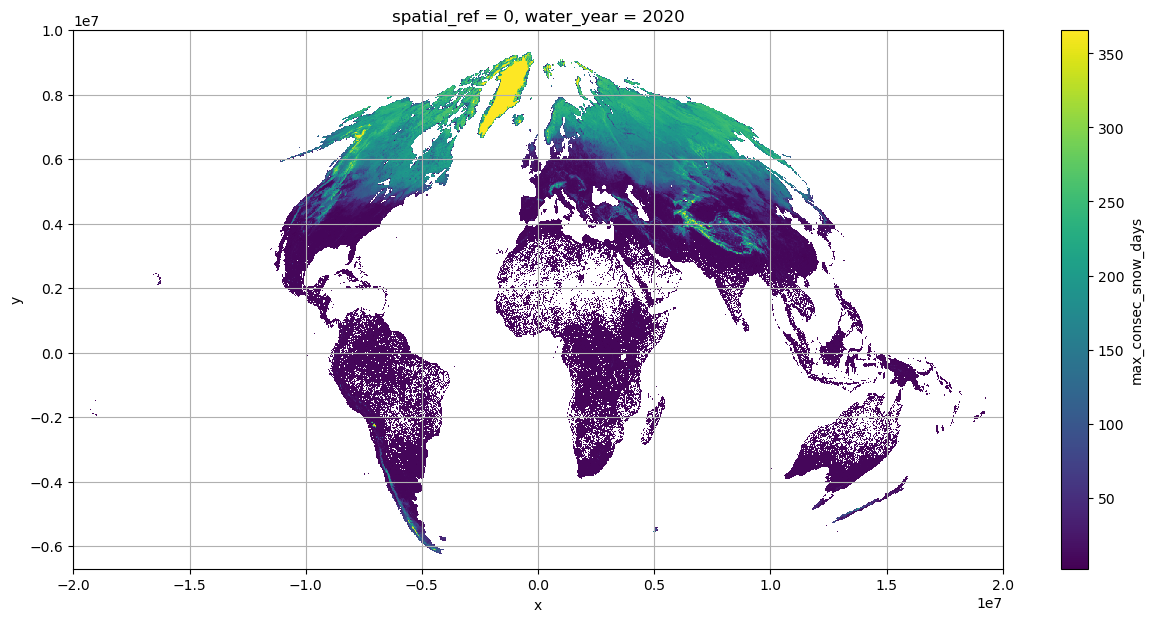

In [37]:
f,ax=plt.subplots(figsize=(15,7))
view_2020_coarse_da.sel(y=slice(None,-0.67E7)).plot.imshow(ax=ax)
ax.grid(True)

In [15]:
seasonal_snow_no_antarctica_da = modis_seasonal_snow_mask_ds['max_consec_snow_days'].sel(y=slice(None,-0.65E7)).astype('int16')
seasonal_snow_no_antarctica_da

<xarray.DataArray 'max_consec_snow_days' (water_year: 10, y: 35629, x: 86400)> Size: 62GB
dask.array<astype, shape=(10, 35629, 86400), dtype=int16, chunksize=(1, 2400, 2400), chunktype=numpy.ndarray>
Coordinates:
    spatial_ref  int64 8B ...
  * water_year   (water_year) int64 80B 2015 2016 2017 2018 ... 2022 2023 2024
  * x            (x) float64 691kB -2.001e+07 -2.001e+07 ... 2.001e+07 2.001e+07
  * y            (y) float64 285kB 1.001e+07 1.001e+07 ... -6.499e+06 -6.5e+06

In [16]:
world_gdf = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")
greenland_gdf = world_gdf[world_gdf['ADMIN'] == 'Greenland']
greenland_gdf

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
22,Admin-0 country,1,3,Denmark,DN1,1,2,Country,1,Greenland,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-46.76379 82.62796, -43.40644 83.225..."


In [17]:
greenland_proj_gdf = greenland_gdf.to_crs(modis_seasonal_snow_mask_ds.rio.crs)
greenland_proj_gdf

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
22,Admin-0 country,1,3,Denmark,DN1,1,2,Country,1,Greenland,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-667208.022 9187820.307, -569381.768..."


In [ ]:
seasonal_snow_no_antarctica_no_greenland_da = seasonal_snow_no_antarctica_da.rio.clip(greenland_proj_gdf.geometry, drop=False, invert=True,)
seasonal_snow_no_antarctica_no_greenland_da

MemoryError: Unable to allocate 22.9 GiB for an array with shape (35629, 86400) and data type int64

In [29]:
def find_snow_area():
    modis_seasonal_snow_mask_ds = xr.open_zarr(config.seasonal_snow_mask_store, decode_coords="all")
    seasonal_snow_no_antarctica_da = modis_seasonal_snow_mask_ds['max_consec_snow_days'].sel(y=slice(None,-0.65E7))
    world_gdf = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")
    greenland_gdf = world_gdf[world_gdf['ADMIN'] == 'Greenland']
    greenland_proj_gdf = greenland_gdf.to_crs(modis_seasonal_snow_mask_ds.rio.crs)
    seasonal_snow_no_antarctica_no_greenland_da = seasonal_snow_no_antarctica_da.rio.clip(greenland_proj_gdf.geometry, drop=False, invert=True,)
    binary_snow_areas_da = xr.where(seasonal_snow_no_antarctica_no_greenland_da >= 56, 1, 0)
    snow_area_per_wy_da = binary_snow_areas_da.sum(dim=['x','y'])*(binary_snow_areas_da.rio.resolution()[0]/1000)**2
    return snow_area_per_wy_da.compute()

In [28]:
client.restart()

In [30]:
future = client.submit(find_snow_area)
future

<Future: pending, key: find_snow_area-7da688ab847cfb2e515672239e70004e>

In [31]:
snow_area_per_wy_da = future.result()
snow_area_per_wy_da

<xarray.DataArray 'max_consec_snow_days' (water_year: 10)> Size: 80B
array([36910810.23863573, 37275503.08902208, 39204414.55035453,
       37409085.39607315, 38029569.17075701, 37505335.55461653,
       37514384.27633067, 37831164.66686121, 38147615.34166957,
       37556623.09279257])
Coordinates:
  * water_year   (water_year) int64 80B 2015 2016 2017 2018 ... 2022 2023 2024
    spatial_ref  int64 8B 0

In [32]:
snow_area_per_wy_df = snow_area_per_wy_da.to_dataframe()

# add our product extent per water year to the dataframe
global_runoff_onset_extent_km2 = [16352898,
16140507,
42703441,
39708851,
39371379,
40497938,
39937778,
23781413,
24026146,
22973905,]

snow_area_per_wy_df['global_runoff_onset_extent_km2'] = global_runoff_onset_extent_km2

snow_area_per_wy_df['pct_of_max_area'] =  snow_area_per_wy_df['global_runoff_onset_extent_km2'] / snow_area_per_wy_df['max_consec_snow_days']
snow_area_per_wy_df

,spatial_ref,max_consec_snow_days,global_runoff_onset_extent_km2,pct_of_max_area
water_year,,,,
2015,0,3.691081e+07,16352898,0.443038
2016,0,3.727550e+07,16140507,0.433006
2017,0,3.920441e+07,42703441,1.089251
2018,0,3.740909e+07,39708851,1.061476
2019,0,3.802957e+07,39371379,1.035283
2020,0,3.750534e+07,40497938,1.079791
2021,0,3.751438e+07,39937778,1.064599
2022,0,3.783116e+07,23781413,0.628620
2023,0,3.814762e+07,24026146,0.629820


In [34]:
snow_area_per_wy_df.to_csv('csvs/modis_snow_area_per_wy_no_antarctica_no_greenland.csv')

In [ ]:
binary_snow_areas_da = xr.where(seasonal_snow_no_antarctica_no_greenland_da >= 56, 1, 0)
binary_snow_areas_da

<xarray.DataArray 'max_consec_snow_days' (water_year: 10, y: 35629, x: 86400)> Size: 246GB
dask.array<where, shape=(10, 35629, 86400), dtype=int64, chunksize=(1, 2400, 2400), chunktype=numpy.ndarray>
Coordinates:
  * water_year  (water_year) int64 80B 2015 2016 2017 2018 ... 2022 2023 2024
  * x           (x) float64 691kB -2.001e+07 -2.001e+07 ... 2.001e+07 2.001e+07
  * y           (y) float64 285kB 1.001e+07 1.001e+07 ... -6.499e+06 -6.5e+06

In [17]:
snow_area_per_wy_da = binary_snow_areas_da.sum(dim=['x','y'])*(binary_snow_areas_da.rio.resolution()[0]/1000)**2
snow_area_per_wy_da

<xarray.DataArray 'max_consec_snow_days' (water_year: 10)> Size: 80B
dask.array<mul, shape=(10,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * water_year  (water_year) int64 80B 2015 2016 2017 2018 ... 2022 2023 2024

In [18]:
snow_area_per_wy_da = snow_area_per_wy_da.compute()
snow_area_per_wy_da

<xarray.DataArray 'max_consec_snow_days' (water_year: 10)> Size: 80B
array([38994366.53070179, 39356882.52748223, 41287886.91087934,
       39492504.73590564, 40111855.1127945 , 39587530.69603521,
       39596749.21275993, 39914157.05059253, 40230361.08258527,
       39639261.50437161])
Coordinates:
  * water_year  (water_year) int64 80B 2015 2016 2017 2018 ... 2022 2023 2024

In [26]:
# adjust for greenland by subtracting out the area of greenland
snow_area_per_wy_no_antarctica_no_greenland_da = snow_area_per_wy_da #- 2166086 # km^2
snow_area_per_wy_no_antarctica_no_greenland_da

<xarray.DataArray 'max_consec_snow_days' (water_year: 10)> Size: 80B
dask.array<mul, shape=(10,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * water_year   (water_year) int64 80B 2015 2016 2017 2018 ... 2022 2023 2024
    spatial_ref  int64 8B 0

In [27]:
snow_area_per_wy_no_antarctica_no_greenland_df = snow_area_per_wy_no_antarctica_no_greenland_da.to_dataframe()
snow_area_per_wy_no_antarctica_no_greenland_df

/home/eric/miniconda3/envs/new_global_snowmelt_runoff_onset/lib/python3.13/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 2.87 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


KeyboardInterrupt: 

In [24]:
# add our product extent per water year to the dataframe
global_runoff_onset_extent_km2 = [16352898,
16140507,
42703441,
39708851,
39371379,
40497938,
39937778,
23781413,
24026146,
22973905,]

snow_area_per_wy_no_antarctica_no_greenland_df['global_runoff_onset_extent_km2'] = global_runoff_onset_extent_km2
snow_area_per_wy_no_antarctica_no_greenland_df


,max_consec_snow_days,global_runoff_onset_extent_km2
water_year,,
2015,3.682828e+07,16352898
2016,3.719080e+07,16140507
2017,3.912180e+07,42703441
2018,3.732642e+07,39708851
2019,3.794577e+07,39371379
2020,3.742144e+07,40497938
2021,3.743066e+07,39937778
2022,3.774807e+07,23781413
2023,3.806428e+07,24026146


,max_consec_snow_days,global_runoff_onset_extent_km2,pct_of_max_area
water_year,,,
2015,3.682828e+07,16352898,0.444031
2016,3.719080e+07,16140507,0.433992
2017,3.912180e+07,42703441,1.091551
2018,3.732642e+07,39708851,1.063827
2019,3.794577e+07,39371379,1.037570
2020,3.742144e+07,40497938,1.082212
2021,3.743066e+07,39937778,1.066980
2022,3.774807e+07,23781413,0.630003
2023,3.806428e+07,24026146,0.631199


In [ ]:
#.to_csv('analysis/csvs/modis_snow_area_per_wy_no_antarctica_no_greenland.csv')

In [ ]:
# url = (f"https://data.earthenv.org/mountains/standard/GMBA_Inventory_v2.0_standard_300.zip")
# gmba_gdf = gpd.read_file("zip+" + url)
# gmba_gdf
#gmba_gdf.filter(['MapName','geometry']).explore(column='MapName')
# gmba_gdf.columns
#gmba_gdf.explore(column='GMBA_V2_ID')

In [ ]:
#gmba_gdf.explore()


In [ ]:
#config.valid_tiles_gdf.explore(column='success',cmap=['red','green'], tiles=xyz.providers.Esri.WorldImagery)

In [ ]:
# global_ds = xr.open_zarr(config.global_runoff_store, consolidated=True, decode_coords='all')

# def view_tile(tile: Tile):


#     test_ds = global_ds.rio.clip_box(*tile.get_geobox().boundingbox,crs='EPSG:4326')
#     test_ds = test_ds.rio.reproject(test_ds.rio.estimate_utm_crs())

#     f,axs=plt.subplots(1,2,figsize=(10,5))
#     test_ds['runoff_onset_median'].plot(ax=axs[0],vmin=0,vmax=365)
#     axs[0].set_title('2015-2024 median snowmelt runoff onset')

#     if 'runoff_onset_std' in test_ds:
#         test_ds['runoff_onset_std'].plot(ax=axs[1],cmap='Reds',vmin=0,vmax=60)
#         axs[1].set_title('2015-2024 std deviation snowmelt runoff onset')
#     elif 'runoff_onset_mad' in test_ds:
#         test_ds['runoff_onset_mad'].plot(ax=axs[1],cmap='Reds',vmin=0,vmax=60)
#         axs[1].set_title('2015-2024 median absolute deviation snowmelt runoff onset')

#     for ax in axs:
#         ctx.add_basemap(ax=ax, crs=test_ds.rio.crs.to_string())
#         ax.set_aspect('equal')
        

#     f.tight_layout()

#     test_ds['runoff_onset'].plot.imshow(col='water_year',col_wrap=5,vmin=0,vmax=365)

#     (test_ds['runoff_onset']-test_ds['runoff_onset_median']).plot.imshow(col='water_year',col_wrap=5,vmin=-60,vmax=60,cmap='RdBu')

In [ ]:
# global_ds = xr.open_zarr(config.global_runoff_store,mask_and_scale=False,consolidated=True, decode_coords='all').sel(longitude=slice(-125,-105),latitude=slice(50,35))#colorado #.sel(longitude=slice(-109,-105),latitude=slice(41,37)) # WUS: .sel(longitude=slice(-125,-105),latitude=slice(50,35))
# global_ds

In [ ]:
# cluster = coiled.Cluster(idle_timeout="10 minutes",
#                          #shutdown_on_close=False,
#                          #wait_for_workers=True,
#                          #n_workers=[41,170], # 170
#                          #n_workers=[31,86],
#                          n_workers=10,
#                          #n_workers=8,
#                          #n_workers=10,
#                          worker_memory="64 GB", #coiled.list_instance_types(backend="azure")
#                          #worker_options={"nthreads": 1},
#                          #worker_options={"nthreads": 32},# 16 8 4 oversubscribe?
#                          #scheduler_memory="256 GB",
#                          #scheduler_memory="128 GB",
#                          spot_policy="spot", # spot usually
#                          #software="sar_snowmelt_timing",
#                          environ={"GDAL_DISABLE_READDIR_ON_OPEN": "EMPTY_DIR"},
#                          #container="mcr.microsoft.com/planetary-computer/python:latest",
#                          workspace="uwtacolab",
                         
#                          )

# client = cluster.get_client()

In [ ]:
# global_ds = xr.open_zarr(config.global_runoff_store, 
#                          consolidated=True, 
#                          decode_coords='all',
#                          #chunks={'latitude': 4096, 'longitude': 4096,'water_year': 10},
#                           #chunks={'latitude': 8192, 'longitude': 8192,'water_year': 1},
#                          )
# global_ds# 

In [ ]:
# coarsen_factor = 100
# #output_path = f'aggregated_results/global_maps/global_coarsened_{coarsen_factor}_ds.nc'
# store = config.azure_blob_fs.get_mapper(f"snowmelt/snowmelt_runoff_onset/coarsened/global_{config.version}_coarsened_{coarsen_factor}_ds.zarr")

# global_ds = xr.open_zarr(config.global_runoff_store, 
#                          consolidated=True, 
#                          decode_coords='all',
#                          )

# global_ds = global_ds.astype
# global_ds.coarsen(
#     latitude=coarsen_factor,
#     longitude=coarsen_factor,
#     boundary='trim').median(
# ).chunk(
#     {'latitude': 8192, 'longitude': 8192,'water_year': 1}).to_zarr(
#         store=store,
#         compute=True, 
#         encoding=encoding,
#         mode='w')

In [ ]:
# global_ds = xr.open_zarr(config.global_runoff_store, 
#                         consolidated=True, 
#                         decode_coords='all',
#                         chunks={"longitude":8640, "latitude":4320}, #config.chunks_zarr_output
#                         )

# global_ds['runoff_onset_mad'] = global_ds['runoff_onset_mad'].astype('float32')
# global_ds['temporal_resolution'] = global_ds['temporal_resolution'].astype('float32')
# global_ds['temporal_resolution_median'] = global_ds['temporal_resolution_median'].astype('float32')

# global_ds

In [38]:
global_ds = xr.open_zarr(config.global_runoff_store, 
                        consolidated=True, 
                        decode_coords='all',
                        chunks={"longitude":8640, "latitude":4320}, #config.chunks_zarr_output,
                        )


global_ds

/tmp/ipykernel_3845452/2794366721.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 4320. This could degrade performance. Instead, consider rechunking after loading.
  global_ds = xr.open_zarr(config.global_runoff_store,
/tmp/ipykernel_3845452/2794366721.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 8640. This could degrade performance. Instead, consider rechunking after loading.
  global_ds = xr.open_zarr(config.global_runoff_store,


<xarray.Dataset> Size: 14TB
Dimensions:                     (latitude: 195970, longitude: 499998,
                                 water_year: 10)
Coordinates:
  * latitude                    (latitude) float64 2MB 81.1 81.1 ... -60.0 -60.0
  * longitude                   (longitude) float64 4MB -180.0 -180.0 ... 180.0
    spatial_ref                 int32 4B ...
  * water_year                  (water_year) int64 80B 2015 2016 ... 2023 2024
Data variables:
    runoff_onset                (water_year, latitude, longitude) float32 4TB dask.array<chunksize=(1, 4320, 8640), meta=np.ndarray>
    runoff_onset_mad            (latitude, longitude) float64 784GB dask.array<chunksize=(4320, 8640), meta=np.ndarray>
    runoff_onset_median         (latitude, longitude) float32 392GB dask.array<chunksize=(4320, 8640), meta=np.ndarray>
    temporal_resolution         (water_year, latitude, longitude) float64 8TB dask.array<chunksize=(1, 4320, 8640), meta=np.ndarray>
    temporal_resolution_median  (latitude, longitude) float64 784GB dask.array<chunksize=(4320, 8640), meta=np.ndarray>
Attributes:
    processed_tiles:  []

In [39]:
global_ds['runoff_onset_mad'] = global_ds['runoff_onset_mad'].astype('float32')
global_ds['temporal_resolution'] = global_ds['temporal_resolution'].astype('float32')
global_ds['temporal_resolution_median'] = global_ds['temporal_resolution_median'].astype('float32')

global_ds

<xarray.Dataset> Size: 9TB
Dimensions:                     (latitude: 195970, longitude: 499998,
                                 water_year: 10)
Coordinates:
  * latitude                    (latitude) float64 2MB 81.1 81.1 ... -60.0 -60.0
  * longitude                   (longitude) float64 4MB -180.0 -180.0 ... 180.0
    spatial_ref                 int32 4B ...
  * water_year                  (water_year) int64 80B 2015 2016 ... 2023 2024
Data variables:
    runoff_onset                (water_year, latitude, longitude) float32 4TB dask.array<chunksize=(1, 4320, 8640), meta=np.ndarray>
    runoff_onset_mad            (latitude, longitude) float32 392GB dask.array<chunksize=(4320, 8640), meta=np.ndarray>
    runoff_onset_median         (latitude, longitude) float32 392GB dask.array<chunksize=(4320, 8640), meta=np.ndarray>
    temporal_resolution         (water_year, latitude, longitude) float32 4TB dask.array<chunksize=(1, 4320, 8640), meta=np.ndarray>
    temporal_resolution_median  (latitude, longitude) float32 392GB dask.array<chunksize=(4320, 8640), meta=np.ndarray>
Attributes:
    processed_tiles:  []

In [ ]:
coarsen_factor = 20

global_coarsened_ds = global_ds.coarsen(
    latitude=coarsen_factor,
    longitude=coarsen_factor,
    
    boundary='trim').mean(
)
    
global_coarsened_ds

In [ ]:
@coiled.function(
    name="coarsen_global_dataset",
    memory="32 GB",
    #cpu=4,
    n_workers=30,  # Adaptive scaling within each function
    idle_timeout="30 minutes",
    keepalive="5 minutes",  # Keep VMs warm between batches
    spot_policy="spot",
    environ={"GDAL_DISABLE_READDIR_ON_OPEN": "EMPTY_DIR"},
    #region="westeurope",
    workspace="uwtacolab",
)
def coarsen_global_ds_and_save(config,coarsen_factor):
    store = config.azure_blob_fs.get_mapper(f"snowmelt/snowmelt_runoff_onset/coarsened/global_{config.version}_coarsened_{coarsen_factor}_ds.zarr")

    chunk_size = config.spatial_chunk_dims_zarr
    nodata_int16 = -9999
    encoding = {
        "runoff_onset": {
            "chunks": (1,) + chunk_size,
            "compressor": zarr.Blosc(cname="zstd"),
            "_FillValue": nodata_int16,
            "dtype": "int16",
        },
        "runoff_onset_median": {
            "chunks": chunk_size,
            "compressor": zarr.Blosc(cname="zstd"),
            "_FillValue": nodata_int16,
            "dtype": "int16",
        },
        "runoff_onset_mad": {
            "chunks": chunk_size,
            "compressor": zarr.Blosc(cname="zstd"),
            "_FillValue": nodata_int16,
            "dtype": "int16",
            "scale_factor": np.float32(0.1),
            "add_offset": np.float32(0.0),
        },
        "temporal_resolution_median": {
            "chunks": chunk_size,
            "compressor": zarr.Blosc(cname="zstd"),
            "_FillValue": nodata_int16,
            "dtype": "int16",
            "scale_factor": np.float32(0.1),
            "add_offset": np.float32(0.0),
        },
        "temporal_resolution": {
            "chunks": (1,) + chunk_size,
            "compressor": zarr.Blosc(cname="zstd"),
            "_FillValue": nodata_int16,
            "dtype": "int16",
            "scale_factor": np.float32(0.1),
            "add_offset": np.float32(0.0),
        },
    }

    global_ds = xr.open_zarr(config.global_runoff_store, 
                            consolidated=True, 
                            decode_coords='all',
                            chunks={"longitude":8640, "latitude":4320}, #config.chunks_zarr_output,
                            )


    global_ds['runoff_onset_mad'] = global_ds['runoff_onset_mad'].astype('float32')
    global_ds['temporal_resolution'] = global_ds['temporal_resolution'].astype('float32')
    global_ds['temporal_resolution_median'] = global_ds['temporal_resolution_median'].astype('float32')

    global_ds.coarsen(
        latitude=coarsen_factor,
        longitude=coarsen_factor,
        
        boundary='trim').mean(
    ).chunk(config.chunks_zarr_output).to_zarr( # take out chunk before zarr \.chunk(config.chunks_zarr_output)
            store=store,
            compute=True, 
            encoding=encoding,
            mode='w')

In [ ]:
coarsen_factor = 20

coarsen_global_ds_and_save(config, coarsen_factor)

In [ ]:
# store = config.azure_blob_fs.get_mapper(f"snowmelt/snowmelt_runoff_onset/coarsened/global_{config.version}_coarsened_{coarsen_factor}_ds.zarr")
# global_coarsened_ds = xr.open_zarr(store)
# global_coarsened_ds

In [ ]:
# coarsen_factor = 20
# store = config.azure_blob_fs.get_mapper(f"snowmelt/snowmelt_runoff_onset/coarsened/global_{config.version}_coarsened_{coarsen_factor}_ds.zarr")
# global_ds.coarsen(
#     latitude=coarsen_factor,
#     longitude=coarsen_factor,
#     boundary='trim').median(
# ).chunk(
#     {'latitude': 8192, 'longitude': 8192,'water_year': 1}).to_zarr(
#         store=store,
#         compute=True, 
#         mode='w')

In [ ]:
#output_path = f'aggregated_results/global_maps/global_coarsened_{coarsen_factor}_ds.nc'
# coarsened_ds = global_ds.coarsen(latitude=coarsen_factor,longitude=coarsen_factor,boundary='trim').median().compute()
# coarsened_ds

In [ ]:
# #global_coarsened_100_ds = xr.open_dataset(output_path) #.sel(longitude=slice(-100,100),latitude=slice(30,50))
# coarsen_factor = 100
# store_100 = config.azure_blob_fs.get_mapper(f"snowmelt/snowmelt_runoff_onset/coarsened/global_v5_coarsened_{coarsen_factor}_ds.zarr")

# global_coarsened_100_ds = xr.open_zarr(store_100)
# global_coarsened_100_ds['runoff_onset_anomaly'] = global_coarsened_100_ds['runoff_onset'] - global_coarsened_100_ds['runoff_onset_median']
# global_coarsened_100_ds = global_coarsened_100_ds.rio.write_crs('EPSG:4326').compute()
# global_coarsened_100_ds

In [ ]:
# coarsen_factor = 20
# store = config.azure_blob_fs.get_mapper(f"snowmelt/snowmelt_runoff_onset/coarsened/global_{config.version}_coarsened_{coarsen_factor}_ds.zarr")
# global_coarsened_ds = xr.open_zarr(store, consolidated=True, decode_coords='all', chunks=None)
# global_coarsened_ds = global_coarsened_ds.rio.write_crs('EPSG:4326')
# global_coarsened_ds

In [3]:
coarsen_factor = 20
store = config.azure_blob_fs.get_mapper(f"snowmelt/snowmelt_runoff_onset/coarsened/global_{config.version}_coarsened_{coarsen_factor}_ds.zarr")
global_coarsened_ds = xr.open_zarr(store, consolidated=True, decode_coords='all', chunks=config.chunks_zarr_output)
# global_coarsened_ds = global_coarsened_ds.coarsen(
#     latitude=2,
#     longitude=2,
#     boundary='trim').median()
#global_coarsened_ds['runoff_onset_anomaly'] = global_coarsened_ds['runoff_onset'] - global_coarsened_ds['runoff_onset_median']
global_coarsened_ds = global_coarsened_ds.rio.write_crs('EPSG:4326')
global_coarsened_ds

<xarray.Dataset> Size: 34GB
Dimensions:                     (latitude: 9798, longitude: 24999,
                                 water_year: 10)
Coordinates:
  * latitude                    (latitude) float64 78kB 81.09 81.08 ... -59.99
  * longitude                   (longitude) float64 200kB -180.0 ... 180.0
    spatial_ref                 int64 8B 0
  * water_year                  (water_year) int64 80B 2015 2016 ... 2023 2024
Data variables:
    runoff_onset                (water_year, latitude, longitude) float32 10GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    runoff_onset_mad            (latitude, longitude) float64 2GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    runoff_onset_median         (latitude, longitude) float32 980MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    temporal_resolution         (water_year, latitude, longitude) float64 20GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    temporal_resolution_median  (latitude, longitude) float64 2GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
Attributes:
    processed_tiles:  []

In [41]:
#global_coarsened_ds['runoff_onset_median'].rio.to_raster("aggregated_results/global_maps/full_global_composite_median.tif", driver="COG", dtype="int16")

In [42]:
global_runoff_onset_median_da = global_coarsened_ds['runoff_onset_median'].astype(np.int16).compute()
global_runoff_onset_median_da

/home/eric/miniconda3/envs/new_global_snowmelt_runoff_onset/lib/python3.13/site-packages/dask/array/chunk.py:279: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)


<xarray.DataArray 'runoff_onset_median' (latitude: 9798, longitude: 24999)> Size: 490MB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(9798, 24999), dtype=int16)
Coordinates:
  * latitude     (latitude) float64 78kB 81.09 81.08 81.06 ... -59.97 -59.99
  * longitude    (longitude) float64 200kB -180.0 -180.0 -180.0 ... 180.0 180.0
    spatial_ref  int64 8B 0
Attributes:
    description:  Median estimated day of water year of snowmelt runoff onset...

In [43]:
# coarsen_factor = 100
# store_100 = config.azure_blob_fs.get_mapper(f"snowmelt/snowmelt_runoff_onset/coarsened/global_v5_coarsened_{coarsen_factor}_ds.zarr")

# global_coarsened_100_ds = xr.open_zarr(store_100)
# global_coarsened_100_ds['runoff_onset_anomaly'] = global_coarsened_100_ds['runoff_onset'] - global_coarsened_100_ds['runoff_onset_median']
# global_coarsened_100_ds = global_coarsened_100_ds.rio.write_crs('EPSG:4326').compute()
# global_coarsened_100_ds

In [ ]:
# to equal area projection
config.valid_tiles_gdf["cell_area_km2"] = config.valid_tiles_gdf.to_crs("EPSG:6933").area / 1e6

: 

In [4]:
import numpy as np
R = 6.371e6

dϕ = np.deg2rad(global_coarsened_ds.rio.resolution()[0])
dλ = np.deg2rad(global_coarsened_ds.rio.resolution()[0])

dlat = R * dϕ * xr.ones_like(global_coarsened_ds['longitude'])
dlon = R * dλ * np.cos(np.deg2rad(global_coarsened_ds['latitude']))
dlon.name = "dlon"
dlat.name = "dlat"

cell_area_m_da = dlon * dlat
cell_area_m_da=cell_area_m_da.rio.write_crs(global_coarsened_ds.rio.crs)
cell_area_km_da = cell_area_m_da / 1e6

surface_area = cell_area_km_da.sum()
print(f"Total surface area of the dataset: {surface_area.values:,.0f} km²")


cell_area_km_da

: 

In [ ]:
for water_year in global_coarsened_ds.water_year.values:
    valid_area_per_wy = cell_area_km_da.where(global_coarsened_ds['runoff_onset'].sel(water_year=water_year) > 0).sum()
    print(f'For water year {water_year} the valid area is {valid_area_per_wy.values:,.0f} km²')

valid_area_median = cell_area_km_da.where(global_coarsened_ds['runoff_onset_median'] > 0).sum()
print(f'For the median snowmelt runoff onset the valid area is {valid_area_median.values:,.0f} km²')

In [ ]:
temporal_resolution_equal_area_da = global_coarsened_ds['temporal_resolution'].rio.reproject('EPSG:8857')
temporal_resolution_equal_area_da

In [ ]:
temporal_resolution_equal_area_da.mean(dim=['x','y'])

In [ ]:
global_coarsened_ds['temporal_resolution_median'].rio.reproject('EPSG:8857').mean(dim=['x','y'])

In [ ]:
global_coarsened_ds['runoff_onset_median']

In [ ]:
coarsen_factor = 20
store_20 = config.azure_blob_fs.get_mapper(f"snowmelt/snowmelt_runoff_onset/coarsened/global_v5_coarsened_{coarsen_factor}_ds.zarr")

global_coarsened_20_ds = xr.open_zarr(store_20)
#global_coarsened_20_ds['runoff_onset_anomaly'] = global_coarsened_20_ds['runoff_onset'] - global_coarsened_20_ds['runoff_onset_median']
global_coarsened_20_ds = global_coarsened_20_ds.rio.write_crs('EPSG:4326')
global_coarsened_20_ds

In [ ]:
global_coarsened_ds["runoff_onset_median"].rio.to_raster("aggregated_results/global_maps/global_composite_median_coarsened_20.tif", driver="COG", dtype="int16")

## 10-year median global runoff onset

In [ ]:
# global_coarsened_ds['runoff_onset_median'].plot.imshow(cmap='viridis',vmin=110,vmax=250)

In [ ]:
f,ax=plt.subplots(figsize=(20,7),subplot_kw=dict(projection=ccrs.EqualEarth()),dpi=300) 

global_coarsened_ds['runoff_onset_median'].plot.imshow(ax=ax,
                                                    cmap='viridis',
                                                    vmin=110,
                                                    vmax=250,
                                                    transform=ccrs.PlateCarree(),
                                                    interpolation='none',
                                                    cbar_kwargs={'label':'DOWY',
                                                                 'orientation':
                                                                 'horizontal',
                                                                 'shrink':0.3,
                                                                 'pad':0.05,
                                                                 'aspect':30})

ax.set_title('') 

gl = ax.gridlines(draw_labels=True, 
                  dms=True, 
                  x_inline=False, 
                  y_inline=False, 
                  xlocs=[-180, -120, -60, 0, 60, 120, 180], 
                  ylocs=[-60, -40, -20, 0, 20, 40, 60, 80], 
                  linestyle='--', 
                  linewidth=0.5,
                  #auto_update=True,
                  )



gl.top_labels=False
gl.bottom_labels=True
gl.right_labels=False
gl.left_labels=True


ax.add_feature(cfeature.LAND, facecolor='lightgrey')
ax.add_feature(cfeature.OCEAN, facecolor='powderblue') 
ax.coastlines(resolution='110m', linewidth=0.5, edgecolor='black')

ax.set_extent([-200, 200, -62, 82], crs=ccrs.PlateCarree())
ax.set_xlim(left=-1.25E7)

f.tight_layout()

f.savefig('figures/global_snowmelt_runoff_onset_median_coarsened_100.png', dpi=300, bbox_inches='tight')

In [ ]:
global_ds = xr.open_zarr(config.global_runoff_store, consolidated=True, decode_coords='all')
global_ds

In [ ]:
europe_bbox = [15, 45, 20, 47]
europe_ds = global_ds.rio.clip_box(*europe_bbox)
europe_ds

In [ ]:
europe_ds['runoff_onset_median'].plot.imshow()

In [ ]:
europe_ds['runoff_onset_median'].coarsen(
    latitude=5,
    longitude=5,
    boundary='trim').median().plot()

In [ ]:
europe_ds['runoff_onset_median'].coarsen(
    latitude=100,
    longitude=100,
    boundary='trim').median(skipna=True).plot()

In [ ]:
europe_bbox = [15, 45, 20, 47]
global_runoff_onset_median_da.rio.clip_box(*europe_bbox).plot.imshow()

## 10-year global snowmelt runoff onset and MAD

In [ ]:
f, axs = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(20, 14),
    subplot_kw=dict(projection=ccrs.Robinson()),
    dpi=300,
    layout="constrained",
)
global_coarsened_ds["runoff_onset_median"].plot.imshow(
    ax=axs[0],
    cmap="viridis",
    vmin=110,
    vmax=250,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={
        "label": "DOWY",
        "orientation": "horizontal",
        "shrink": 0.3,
        "pad": 0.04,
        "aspect": 30,
    },
)

global_coarsened_ds["runoff_onset_mad"].plot.imshow(
    ax=axs[1],
    cmap="Reds",
    vmin=0,
    vmax=30,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={
        "label": "Days",
        "orientation": "horizontal",
        "shrink": 0.3,
        "pad": 0.04,
        "aspect": 30,
    },
)


for ax in axs:
    ax.set_title("")  # 2015-2024 median snowmelt runoff onset

    gl = ax.gridlines(
        draw_labels=True,
        dms=True,
        x_inline=False,
        y_inline=False,
        xlocs=[-180, -120, -60, 0, 60, 120, 180],
        ylocs=[-60, -40, -20, 0, 20, 40, 60, 80],
        linestyle="--",
        linewidth=0.5,
    )
    gl.top_labels = False
    gl.bottom_labels = True
    gl.right_labels = False
    gl.left_labels = True

    ax.set_extent([-180, 180, -62, 82], crs=ccrs.PlateCarree()) # [-180, 180, -62, 82]

    ax.add_feature(cfeature.LAND, facecolor="lightgrey")
    ax.add_feature(cfeature.OCEAN, facecolor="powderblue")  # 'lightcyan'
    ax.coastlines(resolution='110m', linewidth=0.5, edgecolor='black')


f.savefig("figures/global_snowmelt_runoff_onset_median_mad_coarsened_100.png",dpi=300,bbox_inches="tight",)

## Temporal resolution per year

In [ ]:
config.valid_tiles_gdf['tr_median'] = config.valid_tiles_gdf[[f'tr_{year}' for year in range(2015, 2025)]].median(axis=1)

In [ ]:
config.valid_tiles_gdf.plot(column='tr_median',cmap='viridis',legend=True,)

In [ ]:
f, axs = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(30, 15),
    subplot_kw=dict(projection=ccrs.EqualEarth()), # ccrs.Robinson()
    dpi=300,
    #layout="constrained",
)
global_coarsened_ds["runoff_onset_median"].plot(
    ax=axs[0],
    cmap="viridis",
    vmin=110,
    vmax=250,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={
        "label": "DOWY",
        "orientation": "vertical",
        #"shrink": 0.3,
        "pad": 0.01,
        #"aspect": 30,
    },
)

global_coarsened_ds["runoff_onset_mad"].plot(
    ax=axs[1],
    cmap="Reds",
    vmin=0,
    vmax=30,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={
        "label": "Days",
        "orientation": "vertical",
        #"shrink": 0.3,
        "pad": 0.01,
        #"aspect": 30,
    },
)

# config.valid_tiles_gdf.plot(column='tr_median',
#                             cmap='summer',
#                             legend=True,
#                             vmin=2,
#                             vmax=15,
#                             ax=axs[2],
#                             transform=ccrs.PlateCarree(),
#                             legend_kwds={
#                                 "label": "Days",
#                                 "orientation": "vertical",
#                                 #"shrink": 0.3,
#                                 "pad": 0.01,
#                                 #"aspect": 30,
#                             },
#     )

global_coarsened_ds["temporal_resolution_median"].plot(
    ax=axs[2],
    cmap="summer",
    vmin=1,
    vmax=20,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={
        "label": "Days",
        "orientation": "vertical",
        #"shrink": 0.3,
        "pad": 0.01,
        #"aspect": 30,
    },
)

for ax in axs:
    ax.set_title("")  # 2015-2024 median snowmelt runoff onset

    gl = ax.gridlines(
        draw_labels=True,
        dms=True,
        x_inline=False,
        y_inline=False,
        xlocs=[-180, -120, -60, 0, 60, 120, 180],
        ylocs=[-60, -40, -20, 0, 20, 40, 60, 80],
        linestyle="--",
        linewidth=0.5,
    )
    gl.top_labels = False
    gl.bottom_labels = True
    gl.right_labels = False
    gl.left_labels = True

    #ax.set_extent([-180, 180, -62, 82], crs=ccrs.PlateCarree())
    ax.set_extent([-200, 200, -62, 82], crs=ccrs.PlateCarree())
    ax.set_xlim(left=-1.25E7)

    ax.add_feature(cfeature.LAND, facecolor="lightgrey")
    ax.add_feature(cfeature.OCEAN, facecolor="powderblue")  # 'lightcyan'
    ax.coastlines(resolution='110m', linewidth=0.5, edgecolor='black')


f.savefig("figures/global_snowmelt_runoff_onset_median_mad_coarsened_100_and_median_temporal_res.png",dpi=300,bbox_inches="tight",)

f.tight_layout()

## Annual runoff onset maps and anomaly maps

In [ ]:
# now create plots of annual snowmelt runoff onset and anomalies for each water year

f,axs=plt.subplots(nrows=10,ncols=2,figsize=(8,20),subplot_kw=dict(projection=ccrs.Robinson()),dpi=300,layout='constrained') #ccrs.Mollweide()

for water_year in global_coarsened_ds['water_year'].values:
    print(water_year)

    if water_year == 2024:
        colorbar=True
        cbar_dowy = {'label':'DOWY','orientation':'horizontal'} # ,'shrink':0.3,'pad':0.04,'aspect':30
        cbar_days = {'label':'Days','orientation':'horizontal'} # ,'shrink':0.3,'pad':0.04,'aspect':30
    else:
        colorbar=False
        cbar_dowy = None
        cbar_days = None

    ax = axs[int(water_year)-2015,0]
    global_coarsened_ds['runoff_onset'].sel(water_year=water_year).plot.imshow(ax=ax,
                                                                            cmap='viridis',
                                                                            vmin=110,
                                                                            vmax=250,
                                                                            transform=ccrs.PlateCarree(),
                                                                            add_colorbar=colorbar, 
                                                                            cbar_kwargs=cbar_dowy
                                                                            )
    ax.set_title('')

    # plot the anomalies
    ax = axs[int(water_year)-2015,1]
    global_coarsened_ds['runoff_onset_anomaly'].sel(water_year=water_year).plot.imshow(ax=ax,
                                                                                    cmap='RdBu',
                                                                                    vmin=-60,
                                                                                    vmax=60,
                                                                                    transform=ccrs.PlateCarree(),
                                                                                    add_colorbar=colorbar,
                                                                                    cbar_kwargs=cbar_days
                                                                                    )
    ax.set_title('')

for ax in axs.flatten():
    gl = ax.gridlines(draw_labels=False, dms=True, x_inline=False, y_inline=False, xlocs=[-180, -120, -60, 0, 60, 120, 180], ylocs=[-60, -40, -20, 0, 20, 40, 60, 80], linestyle='--', linewidth=0.5)
    gl.top_labels=False
    gl.bottom_labels=False
    gl.right_labels=False
    gl.left_labels=False

    ax.set_extent([-180, 180, -62, 82], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor='lightgrey')
    ax.add_feature(cfeature.OCEAN, facecolor='powderblue') # 'lightcyan'
    ax.coastlines(resolution='110m', linewidth=0.5, edgecolor='black')


f.savefig('figures/global_2015_2024_snowmelt_runoff_onset_and_anomalies.png', dpi=300, bbox_inches='tight')
    

In [ ]:
# now create plots of annual snowmelt runoff onset and anomalies for each water year

f,axs=plt.subplots(nrows=10,ncols=2,figsize=(8,20),subplot_kw=dict(projection=ccrs.Robinson()),dpi=300,layout='constrained') #ccrs.Mollweide()

for water_year in global_coarsened_ds['water_year'].values:
    print(water_year)

    if water_year == 2024:
        colorbar=True
        cbar_dowy = {'label':'DOWY','orientation':'horizontal'} # ,'shrink':0.3,'pad':0.04,'aspect':30
        cbar_days = {'label':'Days','orientation':'horizontal'} # ,'shrink':0.3,'pad':0.04,'aspect':30
    else:
        colorbar=False
        cbar_dowy = None
        cbar_days = None

    ax = axs[int(water_year)-2015,0]
    global_coarsened_ds['runoff_onset'].sel(water_year=water_year).plot.imshow(ax=ax,
                                                                            cmap='viridis',
                                                                            vmin=110,
                                                                            vmax=250,
                                                                            transform=ccrs.PlateCarree(),
                                                                            add_colorbar=colorbar, 
                                                                            cbar_kwargs=cbar_dowy
                                                                            )
    ax.set_title('')

    # plot the anomalies
    ax = axs[int(water_year)-2015,1]

    
    global_coarsened_ds["temporal_resolution"].sel(water_year=water_year).plot.imshow(
        ax=ax,
        cmap="summer",
        vmin=1,
        vmax=20,
        transform=ccrs.PlateCarree(),
        add_colorbar=colorbar,
        cbar_kwargs=cbar_days,
    )



    ax.set_title('')

for ax in axs.flatten():
    gl = ax.gridlines(draw_labels=False, dms=True, x_inline=False, y_inline=False, xlocs=[-180, -120, -60, 0, 60, 120, 180], ylocs=[-60, -40, -20, 0, 20, 40, 60, 80], linestyle='--', linewidth=0.5)
    gl.top_labels=False
    gl.bottom_labels=False
    gl.right_labels=False
    gl.left_labels=False

    ax.set_extent([-180, 180, -62, 82], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor='lightgrey')
    ax.add_feature(cfeature.OCEAN, facecolor='powderblue') # 'lightcyan'
    ax.coastlines(resolution='110m', linewidth=0.5, edgecolor='black')


f.savefig('figures/global_2015_2024_snowmelt_runoff_onset_and_temporal_res.png', dpi=300, bbox_inches='tight')
    

## Define regions

In [ ]:
region_configs = {
    "Western North America": {
        "extent": [-150, -105, 35, 72],
        "position": (-0.12, 0.16, 0.55, 0.5),
        "projection": "albers",
    },
    "High Mountain Asia": {
        "extent": [65, 105, 26, 43],
        "position": (0.63, 0.25, 0.40, 0.37),
        "projection": "albers",
    },
    "South American Andes": {
        "extent": [-75, -65, -57, -20],
        "position": (0.33, 0.02, 0.15, 0.55),
        "projection": "mercator",
    },
    "European Alps": {
        "extent": [5, 16, 43.5, 48.5],
        "position": (0.34, 0.58, 0.12, 0.27),
        "projection": "albers",
    },
    "High Atlas Mountains": {
        "extent": [-10, -4, 31, 33],
        "position": (0.45, 0.35, 0.2, 0.2),
        "projection": "albers",
    },
    "New Zealand Southern Alps": {
        "extent": [166, 179, -48, -34],
        "position": (0.65, 0.02, 0.15, 0.2),
        "projection": "albers",
    }
}

def get_region_projection(region_name, config):
    """Create appropriate projection for a region based on its configuration"""
    extent = config["extent"]
    center_lon = (extent[0] + extent[1]) / 2
    center_lat = (extent[2] + extent[3]) / 2
    
    if config["projection"] == "mercator":
        return ccrs.TransverseMercator(
            central_longitude=center_lon,
            central_latitude=center_lat
        )
    else:  # albers
        return ccrs.AlbersEqualArea(
            central_longitude=center_lon,
            central_latitude=center_lat,
            standard_parallels=(extent[2], extent[3])
        )

## Test region insets

In [ ]:
region_configs = {
    "Western North America": {
        "extent": [-170, -105, 35, 72],
        "position": [0.02, 0.60, 0.30, 0.40],  # Top left
        "polygon": [(-170,72), (-140,72), (-120,63), (-101,35), (-126,35), (-165,55), (-170,72)]
    },
    "South American Andes": {
        "extent": [-75, -65, -57, -20],
        "position": [0.02, 0.00, 0.15, 0.55],  # Left side vertical
        "polygon": [(-75,-20), (-65,-20), (-65,-57), (-75,-57), (-75,-20)]
    },
    "Norway": {
        "extent": [5, 30, 58, 71],
        "position": [0.35, 0.65, 0.15, 0.25],  # Top
        "polygon": [(5,58), (30,58), (30,71), (5,71), (5,58)]
    },
    "European Alps": {
        "extent": [5, 16, 43.5, 48.5],
        "position": [0.55, 0.65, 0.12, 0.25],  # Between Norway and North Asia
        "polygon": [(5,43.5), (16,43.5), (16,48.5), (5,48.5), (5,43.5)]
    },
    "North Asia": {
        "extent": [80, 150, 45, 70],
        "position": [0.75, 0.65, 0.20, 0.25],  # Top right
        "polygon": [(60,70), (120,70), (120,45), (60,45), (60,70)]
    },
    "New Zealand": {
        "extent": [166, 179, -48, -34],
        "position": [0.80, 0.40, 0.12, 0.20],  # Middle right, aligned with HMA
        "polygon": [(166,-34), (179,-34), (179,-48), (166,-48), (166,-34)]
    },
    "High Mountain Asia": {
        "extent": [65, 105, 26, 43],
        "position": [0.60, 0.00, 0.40, 0.25],  # Bottom right
        "polygon": [(65,43), (105,43), (105,26), (65,26), (65,43)]
    },
    "Atlas Mountains": {
        "extent": [-9, 0, 30, 35],
        "position": [0.35, 0.05, 0.12, 0.15],  # Bottom middle left
        "polygon": [(-9,30), (0,30), (0,35), (-9,35), (-9,30)]
    },
    "Caucasus": {
        "extent": [38, 54, 29, 44.75],
        "position": [0.50, 0.05, 0.15, 0.20],  # Bottom middle right
        "polygon": [(38,29), (54,29), (54,44.75), (38,44.75), (38,29)]
    }
}


def draw_connector(ax, start_point, end_point):
    from matplotlib.path import Path
    from matplotlib.patches import PathPatch
    """Draw a curved connector line between map region and inset"""
    # Convert map coordinates to display coordinates
    display_start = ax.transData.transform(ax.projection.transform_point(*start_point, ccrs.PlateCarree()))
    display_end = ax.transAxes.transform(end_point)
    
    # Create curved path
    path = Path([display_start, 
                ((display_start[0] + display_end[0])/2, display_start[1]),
                ((display_start[0] + display_end[0])/2, display_end[1]),
                display_end],
               [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4])
    
    # Draw the path
    patch = PathPatch(path, facecolor='none', edgecolor='black', alpha=0.5, 
                     transform=None, linestyle='--', linewidth=2)
    ax.add_patch(patch)

def create_map_with_insets(global_ds, region_configs):
    # Create figure with Robinson projection
    fig = plt.figure(figsize=(12, 7), dpi=300)
    
    # Add main map in center but smaller
    main_ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
    main_ax.set_extent([-180, 180, -60, 80], ccrs.PlateCarree())
    
    # Make the main map smaller and centered
    main_ax.set_position([0.20, 0.20, 0.6, 0.6])
    
    # Plot main global map with empty title
    global_ds['runoff_onset_median'].plot(
        ax=main_ax,
        transform=ccrs.PlateCarree(),
        cmap='viridis',
        vmin=110,
        vmax=250,
        add_colorbar=False  # Removed colorbar
    )
    main_ax.set_title("")
    
    # Add features to main map
    main_ax.add_feature(cfeature.LAND, facecolor='lightgrey')
    main_ax.add_feature(cfeature.OCEAN, facecolor='powderblue')
    main_ax.coastlines(resolution='50m', linewidth=0.5, edgecolor='black')
    
    # Create insets for each region
    for name, config in region_configs.items():
        # Create inset axis with Robinson projection
        inset = fig.add_axes(
            config["position"],
            projection=ccrs.Robinson()
        )
        
        # Set extent for inset
        inset.set_extent(config["extent"], ccrs.PlateCarree())
        
        # Add features to inset
        inset.add_feature(cfeature.LAND, facecolor='lightgrey')
        inset.add_feature(cfeature.OCEAN, facecolor='powderblue')
        inset.coastlines(resolution='50m', linewidth=0.5, edgecolor='black')
        
        # Plot zoomed data
        global_ds['runoff_onset_median'].sel(
            longitude=slice(config["extent"][0]-1, config["extent"][1]+1),
            latitude=slice(config["extent"][3]+1, config["extent"][2]-1)
        ).plot(
            ax=inset,
            transform=ccrs.PlateCarree(),
            cmap='viridis',
            vmin=110,
            vmax=250,
            add_colorbar=False
        )
        
        # Set empty title
        inset.set_title("")
        inset.set_aspect('equal')
        
        # Draw box on main map
        poly = config["polygon"]
        main_ax.plot(
            [p[0] for p in poly + [poly[0]]],
            [p[1] for p in poly + [poly[0]]],
            color='black',
            linewidth=0.5,
            transform=ccrs.PlateCarree()
        )
        
        # Draw connector
        if "connector" in config:
            draw_connector(main_ax, 
                         config["connector"]["start"],
                         config["connector"]["end"])
    
    return None



In [ ]:
region_configs = {
    "Western North America": {
        "extent": [-170, -105, 35, 72],
        "position": [0.01, 0.55, 0.36, 0.5],  # Standardized width
        "x_lims": [-1.25E7, -0.9E7],
        "y_lims": None,
    },
    "South American Andes": {
        "extent": [-75, -65, -57, -20],
        "position": [0.01, 0.0, 0.2, 0.535],  # Matching WNA width
    },
    "Norway": {
        "extent": [5, 30, 58, 71],
        "position": [0.3, 0.70, 0.18, 0.28],  # Top row - equal width
        "x_lims": [0.34E6, 1.3E6],
        "y_lims": [6.1E6, 7.3E6],
    },
    "European Alps": {
        "extent": [5, 16, 43.5, 48.5],
        "position": [0.5, 0.70, 0.3, 0.28],  # Top row - equal width
    },
    "North Asia": {
        "extent": [85, 170, 45, 70],
        "position": [0.7, 0.70, 0.4, 0.28],  # Top row - adjusted
        "x_lims": [0.8E7, 1.3E7],
    },
    "New Zealand": {
        "extent": [166, 179, -48, -34],
        "position": [0.80, 0.35, 0.19, 0.28],  # Right middle - adjusted
    },
    "High Mountain Asia": {
        "extent": [65, 105, 26, 43],
        "position": [0.65, 0.01, 0.38, 0.3],  # Bottom right - height adjusted
    },
    "Atlas Mountains": {
        "extent": [-10, -3, 30, 35],
        "position": [0.2, 0.01, 0.2, 0.3],  # Bottom left - consistent height
    },
    "Caucasus": {
        "extent": [38, 54, 29, 44.75],
        "position": [0.4, 0.01, 0.18, 0.3],  # Bottom middle - consistent height
    }
}

def create_map_with_insets(global_ds, region_configs):
    # Create figure with better size ratio
    fig = plt.figure(figsize=(16, 9), dpi=300)
    
    # Add main map in center
    main_ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
    main_ax.set_extent([-180, 180, -60, 80], ccrs.PlateCarree())
    
    # Position the main map - slightly adjusted
    main_ax.set_position([0.27, 0.20, 0.48, 0.58])
    
    # Plot main global map
    global_ds['runoff_onset_median'].plot.imshow(
        ax=main_ax,
        transform=ccrs.PlateCarree(),
        cmap='viridis',
        vmin=110,
        vmax=250,
        add_colorbar=False
    )
    
    # Add features to main map
    main_ax.add_feature(cfeature.LAND, facecolor='lightgrey')
    main_ax.add_feature(cfeature.OCEAN, facecolor='powderblue')
    main_ax.coastlines(resolution='50m', linewidth=0.5, edgecolor='black')
    
    # Set title to empty AFTER plotting
    main_ax.set_title("")
    
    # Create insets for each region
    for name, region_config in region_configs.items():
        # Create inset axis with Robinson projection
        inset = fig.add_axes(
            region_config["position"],
            projection=ccrs.Robinson()
        )
        
        # Set extent for inset
        inset.set_extent(region_config["extent"], ccrs.PlateCarree())
        
        # Add features to inset
        inset.add_feature(cfeature.LAND, facecolor='lightgrey')
        inset.add_feature(cfeature.OCEAN, facecolor='powderblue')
        inset.coastlines(resolution='50m', linewidth=0.5, edgecolor='black')
        
        # Plot zoomed data
        global_ds['runoff_onset_median'].sel(
            longitude=slice(region_config["extent"][0]-10, region_config["extent"][1]+10),
            latitude=slice(region_config["extent"][3]+10, region_config["extent"][2]-10)
        ).plot.imshow(
            ax=inset,
            transform=ccrs.PlateCarree(),
            cmap='viridis',
            vmin=110,
            vmax=250,
            add_colorbar=False
        )
        
        # CRITICAL: Set title to empty AFTER plotting
        inset.set_title("")
        
        # Add region name label
        inset.text(
            0.5, 0.08, name,
            transform=inset.transAxes,
            ha='center', va='bottom',
            fontsize=8, fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='black', boxstyle='round,pad=0.1')
        )

        if "y_lims" in region_config:
            if region_config["y_lims"] is not None:
                inset.set_ylim(region_config["y_lims"])
        
        if "x_lims" in region_config:
            if region_config["x_lims"] is not None:
                inset.set_xlim(region_config["x_lims"])
            
        # Draw rectangle on main map with updated extents
        extent = region_config["extent"]
        box = [
            (extent[0], extent[2]), (extent[1], extent[2]),
            (extent[1], extent[3]), (extent[0], extent[3])
        ]
        
        main_ax.plot(
            [box[0][0], box[1][0], box[2][0], box[3][0], box[0][0]],
            [box[0][1], box[1][1], box[2][1], box[3][1], box[0][1]],
            color='black',
            linewidth=0.5,
            transform=ccrs.PlateCarree()
        )
    
    return None

In [ ]:
create_map_with_insets(global_coarsened_100_ds, region_configs)


In [ ]:
f,ax=plt.subplots(figsize=(20,7),subplot_kw=dict(projection=ccrs.Robinson()),dpi=300) #ccrs.Mollweide()


ax.set_title('') 

gl = ax.gridlines(draw_labels=True, 
                  dms=True, 
                  x_inline=False, 
                  y_inline=False, 
                  xlocs=[-180, -120, -60, 0, 60, 120, 180], 
                  ylocs=[-60, -40, -20, 0, 20, 40, 60, 80], 
                  linestyle='--', 
                  linewidth=0.5,
                  auto_update=True,
                  )



gl.top_labels=False
gl.bottom_labels=True
gl.right_labels=False
gl.left_labels=True


ax.add_feature(cfeature.LAND, facecolor='lightgrey')
ax.add_feature(cfeature.OCEAN, facecolor='powderblue') # 'lightcyan'
ax.coastlines(resolution='110m', linewidth=0.5, edgecolor='black')

ax.set_extent([-180, 180, -62, 82], crs=ccrs.PlateCarree())


for region_name, region_config in region_configs.items():
    projection = get_region_projection(region_name, region_config)
    
    axins = inset_axes(ax, 
                      width="100%", height="100%",
                      bbox_to_anchor=region_config["position"],
                      bbox_transform=ax.transAxes,
                      axes_class=cartopy.mpl.geoaxes.GeoAxes,
                      axes_kwargs=dict(projection=projection))
    
    extent = region_config["extent"]
    axins.set_extent(extent, crs=ccrs.PlateCarree())

    axins.add_feature(cfeature.LAND, facecolor='lightgrey', zorder=0)
    axins.add_feature(cfeature.OCEAN, facecolor='powderblue', zorder=0)
    axins.coastlines(resolution='50m', linewidth=0.5, edgecolor='black')
    
    x = [extent[0], extent[1], extent[1], extent[0], extent[0]]
    y = [extent[2], extent[2], extent[3], extent[3], extent[2]]
    ax.plot(x, y, color='k', alpha=0.8, transform=ccrs.PlateCarree())

## 10-year median global runoff onset with regional insets

In [ ]:
# FOR FINAL FIGURES, CHANGE .plot.imshow() to .plot()

f, ax = plt.subplots(
    figsize=(20, 7), subplot_kw=dict(projection=ccrs.Robinson()), dpi=300
)

global_coarsened_100_ds["runoff_onset_median"].plot.imshow(
    ax=ax,
    cmap="viridis",
    vmin=110,
    vmax=250,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={
        "label": "DOWY",
        "orientation": "horizontal",
        "shrink": 0.3,
        "pad": 0.05,
        "aspect": 30,
    },
)

ax.set_title("")

gl = ax.gridlines(
    draw_labels=True,
    dms=True,
    x_inline=False,
    y_inline=False,
    xlocs=[-180, -120, -60, 0, 60, 120, 180],
    ylocs=[-60, -40, -20, 0, 20, 40, 60, 80],
    linestyle="--",
    linewidth=0.5,
    auto_update=True,
)


gl.top_labels = False
gl.bottom_labels = True
gl.right_labels = False
gl.left_labels = True


ax.add_feature(cfeature.LAND, facecolor="lightgrey")
ax.add_feature(cfeature.OCEAN, facecolor="powderblue")
ax.coastlines(resolution="110m", linewidth=0.5, edgecolor="black")

ax.set_extent([-180, 180, -62, 82], crs=ccrs.PlateCarree())


for region_name, region_config in region_configs.items():
    projection = get_region_projection(region_name, region_config)

    axins = inset_axes(
        ax,
        width="100%",
        height="100%",
        bbox_to_anchor=region_config["position"],
        bbox_transform=ax.transAxes,
        axes_class=cartopy.mpl.geoaxes.GeoAxes,
        axes_kwargs=dict(projection=projection),
    )

    extent = region_config["extent"]
    axins.set_extent(extent, crs=ccrs.PlateCarree())

    axins.add_feature(cfeature.LAND, facecolor="lightgrey", zorder=0)
    axins.add_feature(cfeature.OCEAN, facecolor="powderblue", zorder=0)
    axins.coastlines(resolution="50m", linewidth=0.5, edgecolor="black")

    global_coarsened_20_ds["runoff_onset_median"].sel(
        longitude=slice(extent[0] - 20, extent[1] + 20),
        latitude=slice(extent[3] + 20, extent[2] - 20),
    ).plot.imshow(
        ax=axins,
        cmap="viridis",
        vmin=110,
        vmax=250,
        transform=ccrs.PlateCarree(),
        add_colorbar=False,
    )

    axins.set_title("")

    x = [extent[0], extent[1], extent[1], extent[0], extent[0]]
    y = [extent[2], extent[2], extent[3], extent[3], extent[2]]
    ax.plot(x, y, color="k", alpha=0.8, transform=ccrs.PlateCarree())

In [ ]:
# Create the two-panel figure with insets
f, axs = plt.subplots(nrows=2, ncols=1, 
                      figsize=(20, 14),
                      subplot_kw=dict(projection=ccrs.Robinson()), 
                      dpi=300, layout='constrained')

# Plot main data
global_coarsened_100_ds['runoff_onset_median'].plot.imshow(
    ax=axs[0], cmap='viridis', vmin=110, vmax=250,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label':'DOWY', 'orientation':'horizontal', 
                'shrink':0.3, 'pad':0.04, 'aspect':30}
)

global_coarsened_100_ds['runoff_onset_mad'].plot.imshow(
    ax=axs[1], cmap='Reds', vmin=0, vmax=30,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={'label':'Days', 'orientation':'horizontal', 
                'shrink':0.3, 'pad':0.04, 'aspect':30}
)

# Configure both main maps
for ax in axs:
    ax.set_title('')
    
    # Add gridlines
    gl = ax.gridlines(
        draw_labels=True, dms=True,
        x_inline=False, y_inline=False,
        xlocs=[-180, -120, -60, 0, 60, 120, 180],
        ylocs=[-60, -40, -20, 0, 20, 40, 60, 80],
        linestyle='--', linewidth=0.5
    )
    gl.top_labels = False
    gl.bottom_labels = True
    gl.right_labels = False
    gl.left_labels = True
    
    # Set map extent and features
    ax.set_extent([-180, 180, -62, 82], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='lightgrey')
    ax.add_feature(cfeature.OCEAN, facecolor='powderblue')
    ax.coastlines(resolution='110m', linewidth=0.5, edgecolor='black')
    
    # Add insets to both panels
    for region_name, region_config in region_configs.items():
        projection = get_region_projection(region_name, region_config)
        
        axins = inset_axes(
            ax,
            width="100%", height="100%",
            bbox_to_anchor=config["position"],
            bbox_transform=ax.transAxes,
            axes_class=cartopy.mpl.geoaxes.GeoAxes,
            axes_kwargs=dict(projection=projection)
        )
        
        # Set inset extent and features
        extent = region_config["extent"]
        axins.set_extent(extent, crs=ccrs.PlateCarree())
        axins.add_feature(cfeature.LAND, facecolor='lightgrey', zorder=0)
        axins.add_feature(cfeature.OCEAN, facecolor='powderblue', zorder=0)
        axins.coastlines(resolution='50m', linewidth=0.5, edgecolor='black')
        
        # Plot regional data - different variables for each panel
        if ax == axs[0]:  # Top panel - median
            global_coarsened_20_ds["runoff_onset_median"].sel(
                longitude=slice(extent[0] - 20, extent[1] + 20),
                latitude=slice(extent[3] + 20, extent[2] - 20),
            ).plot.imshow(
                ax=axins,
                cmap='viridis',
                vmin=110, vmax=250,
                transform=ccrs.PlateCarree(),
                add_colorbar=False
            )
        else:  # Bottom panel - MAD
            global_coarsened_20_ds["runoff_onset_mad"].sel(
                longitude=slice(extent[0] - 20, extent[1] + 20),
                latitude=slice(extent[3] + 20, extent[2] - 20),
            ).plot.imshow(
                ax=axins,
                cmap='Reds',
                vmin=0, vmax=30,
                transform=ccrs.PlateCarree(),
                add_colorbar=False
            )
        
        # Draw rectangle on main map
        x = [extent[0], extent[1], extent[1], extent[0], extent[0]]
        y = [extent[2], extent[2], extent[3], extent[3], extent[2]]
        ax.plot(x, y, color='k', alpha=0.8, transform=ccrs.PlateCarree())
        
        # Optional: Add region labels
        #axins.set_title(region_name, fontsize=10, pad=8)
        axins.set_title("")



In [ ]:
seasonal_snow_mask = xr.open_zarr(config.seasonal_snow_mask_store, consolidated=True, decode_coords='all') 
seasonal_snow_mask

In [ ]:
import easysnowdata

In [ ]:
easysnowdata.utils.convert_bbox_to_geodataframe?

In [ ]:
# bounding box for alaska in a list
coords = (-140, 55, -120, 68)
bbox_gdf = easysnowdata.utils.convert_bbox_to_geodataframe(bbox_input=coords)
bbox_gdf

In [ ]:
bbox_gdf.explore()

In [ ]:
bbox_gdf.total_bounds

In [ ]:
seasonal_snow_mask_clip_test_ds = seasonal_snow_mask.rio.clip_box(*bbox_gdf.total_bounds,crs=bbox_gdf.crs)
seasonal_snow_mask_clip_test_ds

In [ ]:
seasonal_snow_mask_clip_test_ds.isel(water_year=slice(0,2)).to_dataarray().plot.imshow(row='water_year',col='variable',vmin=0,vmax=365)

In [ ]:
seasonal_snow_mask_clip_test_ds.isel(water_year=slice(0,2)).to_dataarray().plot.imshow(row='water_year',col='variable',vmin=50,vmax=150)

In [ ]:
seasonal_snow_mask_clip_test_ds.isel(water_year=slice(0,2)).to_dataarray().plot.imshow(row='water_year',col='variable',vmin=170,vmax=250)

In [ ]:
f,ax=plt.subplots(figsize=(20,7),subplot_kw=dict(projection=ccrs.Robinson()),dpi=300) #ccrs.Mollweide()

global_coarsened_100_ds['runoff_onset_median'].plot(ax=ax, cmap='viridis', vmin=110, vmax=250, transform=ccrs.PlateCarree(), add_colorbar=False)

ax.set_title('') 

gl = ax.gridlines(draw_labels=True, 
                  dms=True, 
                  x_inline=False, 
                  y_inline=False, 
                  xlocs=[-180, -120, -60, 0, 60, 120, 180], 
                  ylocs=[-60, -40, -20, 0, 20, 40, 60, 80], 
                  linestyle='--', 
                  linewidth=0.5,
                  auto_update=True,
                  )



gl.top_labels=False
gl.bottom_labels=True
gl.right_labels=False
gl.left_labels=True



ax.add_feature(cfeature.LAND, facecolor='lightgrey')
ax.add_feature(cfeature.OCEAN, facecolor='powderblue') # 'lightcyan'
ax.coastlines(resolution='110m', linewidth=0.5, edgecolor='black')

ax.set_extent([-180, 180, -62, 82], crs=ccrs.PlateCarree())

        
# Add insets with equal-area projection and fixed placement
inset_regions = {
    "Western North America": [-150, -105, 35, 72],
    "High Mountain Asia": [65, 105, 26, 43],
    "South American Andes": [-75, -65, -57, -20],
    "European Alps": [5, 16, 43.5, 48.5],
    "High Atlas Mountains": [-10, -4, 31, 33],
    "New Zealand Southern Alps": [166, 179, -48, -34],
}

# Adjusted logical placement of inset boxes
inset_positions = {
    "Western North America": (-0.12, 0.16, 0.55, 0.5),  # To the west of South America
    "High Mountain Asia": (0.63, 0.25, 0.40, 0.37),      # Between Africa and Australia
    "South American Andes": (0.33, 0.02, 0.15, 0.55),     # Directly to the east of South America
    "European Alps": (0.34, 0.58, 0.12, 0.27),            # Between Africa and Europe
    "High Atlas Mountains": (0.45, 0.35, 0.2, 0.2),     # Between Africa and Europe
    "New Zealand Southern Alps": (0.65, 0.02, 0.15, 0.2), # Between Australia and Antarctica
}

for region_name, extent in inset_regions.items():
    # Calculate the center of the region for the equal-area projection
    center_lon = (extent[0] + extent[1]) / 2
    center_lat = (extent[2] + extent[3]) / 2

    if region_name == "South American Andes":
        projection = ccrs.TransverseMercator(central_longitude=center_lon, central_latitude=center_lat)
    else:
        projection = ccrs.AlbersEqualArea(central_longitude=center_lon, central_latitude=center_lat, standard_parallels=(extent[2], extent[3]))

    pos = inset_positions[region_name]
    axins = inset_axes(ax, width="100%", height="100%", bbox_to_anchor=pos,
                       bbox_transform=ax.transAxes, axes_class=cartopy.mpl.geoaxes.GeoAxes,
                       axes_kwargs=dict(projection=projection))
    axins.set_extent(extent, crs=ccrs.PlateCarree())
    axins.add_feature(cfeature.LAND, facecolor='lightgrey', zorder=0)
    axins.add_feature(cfeature.OCEAN, facecolor='powderblue', zorder=0)
    axins.coastlines(resolution='110m', linewidth=0.5, edgecolor='black')


    # Plot the same data as the global map but zoomed in
    #global_coarsened_100_ds['runoff_onset_median'].plot(ax=axins, cmap='viridis', vmin=110, vmax=250, transform=ccrs.PlateCarree(), add_colorbar=False)
    
    global_coarsened_20_ds['runoff_onset_median'].sel(longitude=slice(extent[0]-20, extent[1]+20), latitude=slice(extent[3]+20, extent[2]-20)).plot(ax=axins, cmap='viridis', vmin=110, vmax=250, transform=ccrs.PlateCarree(), add_colorbar=False)
    axins.set_title("")

    # gls = axins.gridlines(draw_labels=True,
    #                 #dms=True,
    #                 x_inline=True,
    #                 y_inline=True,
    #                 linestyle='--',
    #                 linewidth=0.5,
    #                 auto_update=True,
    #                )
    
    # gls.xlabel_style = {'size': 15, 'color': 'gray'}
    # gls.xlabel_style = {'color': 'red', 'weight': 'bold'}

    # gls.top_labels=False
    # gls.bottom_labels=True
    # gls.right_labels=False
    # gls.left_labels=True
    #axins.set_title(region_name, fontsize=10)

    # Add a rectangle on the main map to indicate the inset region
    x = [extent[0], extent[1], extent[1], extent[0], extent[0]]
    y = [extent[2], extent[2], extent[3], extent[3], extent[2]]
    ax.plot(x, y, color='k', alpha=0.8, transform=ccrs.PlateCarree())



In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Main map with insets
f, axs = plt.subplots(nrows=2, ncols=1, figsize=(20, 14), 
                      subplot_kw=dict(projection=ccrs.Robinson()), 
                      dpi=300, layout='constrained')

# # Plot the main data
# global_coarsened_100_ds['runoff_onset_median'].plot(
#     ax=axs[0], cmap='viridis', vmin=110, vmax=250, 
#     transform=ccrs.PlateCarree(),
#     cbar_kwargs={'label':'DOWY','orientation':'horizontal','shrink':0.3,'pad':0.04,'aspect':30}
# )

# global_coarsened_100_ds['runoff_onset_mad'].plot(
#     ax=axs[1], cmap='Reds', vmin=0, vmax=30, 
#     transform=ccrs.PlateCarree(),
#     cbar_kwargs={'label':'Days','orientation':'horizontal','shrink':0.3,'pad':0.04,'aspect':30}
# )

# Configure main maps
for ax in axs:
    ax.set_title('')
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                      xlocs=[-180, -120, -60, 0, 60, 120, 180], 
                      ylocs=[-60, -40, -20, 0, 20, 40, 60, 80],
                      linestyle='--', linewidth=0.5)
    gl.top_labels = False
    gl.bottom_labels = True
    gl.right_labels = False
    gl.left_labels = True
    
    ax.set_extent([-180, 180, -62, 82], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='lightgrey')
    ax.add_feature(cfeature.OCEAN, facecolor='powderblue')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='black')

# Define inset regions with refined extents
inset_regions = {
    "Western North America": [-140, -105, 35, 65],  # Adjusted to focus on key snow regions
    "High Mountain Asia": [65, 105, 25, 45],        # Centered on Himalayas and surrounding ranges
    "South American Andes": [-75, -65, -50, -15]    # Focused on Andes range
}

# Adjusted inset positions to avoid overlap
inset_positions = {
    "Western North America": (0.02, 0.55, 0.35, 0.35),     # Top left
    "High Mountain Asia": (0.65, 0.55, 0.35, 0.35),        # Top right
    "South American Andes": (0.35, 0.02, 0.35, 0.35)       # Bottom center
}

for region_name, extent in inset_regions.items():
    # Calculate center for equal-area projection
    center_lon = (extent[0] + extent[1]) / 2
    center_lat = (extent[2] + extent[3]) / 2
    
    # Create equal-area projection centered on region
    projection = ccrs.AlbersEqualArea(
        central_longitude=center_lon,
        central_latitude=center_lat,
        #standard_parallels=(extent[2], extent[3])
    )
    
    # Create inset
    pos = inset_positions[region_name]
    axins = inset_axes(axs[0], 
                      width="100%", height="100%",
                      loc='center',
                      bbox_to_anchor=pos,
                      bbox_transform=axs[0].transAxes,
                      axes_class=cartopy.mpl.geoaxes.GeoAxes,
                      axes_kwargs=dict(map_projection=projection))
    
    # Set extent and add features
    axins.set_extent(extent, crs=ccrs.PlateCarree())
    axins.add_feature(cfeature.LAND, facecolor='lightgrey', zorder=0)
    axins.add_feature(cfeature.OCEAN, facecolor='powderblue', zorder=0)
    axins.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='black')
    
    # Add data to inset
    # global_coarsened_20_ds['runoff_onset_median'].plot(
    #     ax=axins, cmap='viridis', vmin=110, vmax=250,
    #     transform=ccrs.PlateCarree(), add_colorbar=False
    # )
    
    # Add title
    axins.set_title(region_name, fontsize=10, pad=8)
    
    # Draw box on main map
    x = [extent[0], extent[1], extent[1], extent[0], extent[0]]
    y = [extent[2], extent[2], extent[3], extent[3], extent[2]]
    rect = axs[0].plot(x, y, color='k', alpha=0.8, transform=ccrs.PlateCarree())[0]
    
    # Add connectors properly aligned to the inset box corners
    axins.spines['geo'].set_visible(True)
    
    # # Draw connectors manually using the correct coordinate systems
    # for corner_x, corner_y in zip([extent[0], extent[1]], [extent[2], extent[3]]):
    #     axs[0].plot([corner_x, pos[0]], [corner_y, pos[1]], 
    #                 color='black', alpha=0.5, linestyle='-', 
    #                 transform=ccrs.PlateCarree())

#plt.show()

In [ ]:
# should have global temporal resolution and spatial coverage for each water year

In [ ]:
# now create plots of annual snowmelt runoff onset and anomalies for each water year

f,axs=plt.subplots(nrows=10,ncols=2,figsize=(8,20),subplot_kw=dict(projection=ccrs.Robinson()),dpi=300,layout='constrained') #ccrs.Mollweide()

for water_year in global_coarsened_100_ds['water_year'].values:
    print(water_year)

    if water_year == 2024:
        colorbar=True
        cbar_dowy = {'label':'DOWY','orientation':'horizontal'} # ,'shrink':0.3,'pad':0.04,'aspect':30
        cbar_days = {'label':'Days','orientation':'horizontal'} # ,'shrink':0.3,'pad':0.04,'aspect':30
    else:
        colorbar=False
        cbar_dowy = None
        cbar_days = None

    ax = axs[int(water_year)-2015,0]
    global_coarsened_100_ds['runoff_onset'].sel(water_year=water_year).plot(ax=ax,
                                                                            cmap='viridis',
                                                                            vmin=110,
                                                                            vmax=250,
                                                                            transform=ccrs.PlateCarree(),
                                                                            add_colorbar=colorbar, 
                                                                            cbar_kwargs=cbar_dowy
                                                                            )
    ax.set_title('')

    # plot the anomalies
    ax = axs[int(water_year)-2015,1]
    global_coarsened_100_ds['runoff_onset_anomaly'].sel(water_year=water_year).plot(ax=ax,
                                                                                    cmap='RdBu',
                                                                                    vmin=-60,
                                                                                    vmax=60,
                                                                                    transform=ccrs.PlateCarree(),
                                                                                    add_colorbar=colorbar,
                                                                                    cbar_kwargs=cbar_days
                                                                                    )
    ax.set_title('')

for ax in axs.flatten():
    gl = ax.gridlines(draw_labels=False, dms=True, x_inline=False, y_inline=False, xlocs=[-180, -120, -60, 0, 60, 120, 180], ylocs=[-60, -40, -20, 0, 20, 40, 60, 80], linestyle='--', linewidth=0.5)
    gl.top_labels=False
    gl.bottom_labels=False
    gl.right_labels=False
    gl.left_labels=False

    ax.set_extent([-180, 180, -62, 82], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor='lightgrey')
    ax.add_feature(cfeature.OCEAN, facecolor='powderblue') # 'lightcyan'
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='black')


f.savefig('figures/global_2015_2024_snowmelt_runoff_onset_and_anomalies.png', dpi=300)
    

In [ ]:
hma_coarsened_20_ds = global_coarsened_20_ds.sel(longitude=slice(50,110),latitude=slice(50,20)).compute()
hma_coarsened_20_ds

In [ ]:
# now create plots of annual snowmelt runoff onset and anomalies for each water year

f,axs=plt.subplots(nrows=10,
                   ncols=2,
                   figsize=(8,20),
                   subplot_kw=dict(projection=ccrs.AlbersEqualArea(
                       central_latitude=hma_coarsened_20_ds.latitude.median().values,
                       central_longitude=hma_coarsened_20_ds.longitude.median().values)),
                       dpi=300,
                       layout='constrained') #ccrs.Mollweide()

for water_year in hma_coarsened_20_ds['water_year'].values:
    print(water_year)

    if water_year == 2024:
        colorbar=True
        cbar_dowy = {'label':'DOWY','orientation':'horizontal'} # ,'shrink':0.3,'pad':0.04,'aspect':30
        cbar_days = {'label':'Days','orientation':'horizontal'} # ,'shrink':0.3,'pad':0.04,'aspect':30
    else:
        colorbar=False
        cbar_dowy = None
        cbar_days = None

    ax = axs[int(water_year)-2015,0]
    hma_coarsened_20_ds['runoff_onset'].sel(water_year=water_year).plot(ax=ax,
                                                                            cmap='viridis',
                                                                            vmin=110,
                                                                            vmax=250,
                                                                            transform=ccrs.PlateCarree(),
                                                                            add_colorbar=colorbar, 
                                                                            cbar_kwargs=cbar_dowy
                                                                            )
    ax.set_title('')

    # plot the anomalies
    ax = axs[int(water_year)-2015,1]
    hma_coarsened_20_ds['runoff_onset_anomaly'].sel(water_year=water_year).plot(ax=ax,
                                                                                    cmap='RdBu',
                                                                                    vmin=-60,
                                                                                    vmax=60,
                                                                                    transform=ccrs.PlateCarree(),
                                                                                    add_colorbar=colorbar,
                                                                                    cbar_kwargs=cbar_days
                                                                                    )
    ax.set_title('')

for ax in axs.flatten():
    gl = ax.gridlines(draw_labels=True, 
                      dms=True, 
                      x_inline=False, 
                      y_inline=False, 
                      #xlocs=[-180, -120, -60, 0, 60, 120, 180], 
                      #ylocs=[-60, -40, -20, 0, 20, 40, 60, 80], 
                      linestyle='--', 
                      linewidth=0.5
                      )
    gl.top_labels=False
    gl.bottom_labels=False
    gl.right_labels=False
    gl.left_labels=False

    #ax.set_extent([-180, 180, -62, 82], crs=ccrs.PlateCarree())
    ax.set_extent([60, 110, 25, 45], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor='lightgrey')
    ax.add_feature(cfeature.OCEAN, facecolor='powderblue') # 'lightcyan'
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='black')


f.savefig('figures/hma_2015_2024_snowmelt_runoff_onset_and_anomalies_zoomed.png', dpi=300)
    

In [ ]:
hma_coarsened_20_ds['runoff_onset'].isel(water_year=-1).plot.imshow()

In [ ]:
wna_coarsened_20_ds = global_coarsened_20_ds.sel(longitude=slice(-170,-100),latitude=slice(70,30)).compute()
wna_coarsened_20_ds

In [ ]:
# now create plots of annual snowmelt runoff onset and anomalies for each water year

f,axs=plt.subplots(nrows=10,ncols=2,figsize=(8,20),subplot_kw=dict(projection=ccrs.Robinson()),dpi=300,layout='constrained') #ccrs.Mollweide()

for water_year in wna_coarsened_20_ds['water_year'].values:
    print(water_year)

    if water_year == 2024:
        colorbar=True
        cbar_dowy = {'label':'DOWY','orientation':'horizontal'} # ,'shrink':0.3,'pad':0.04,'aspect':30
        cbar_days = {'label':'Days','orientation':'horizontal'} # ,'shrink':0.3,'pad':0.04,'aspect':30
    else:
        colorbar=False
        cbar_dowy = None
        cbar_days = None

    ax = axs[int(water_year)-2015,0]
    wna_coarsened_20_ds['runoff_onset'].sel(water_year=water_year).plot.imshow(ax=ax,
                                                                            cmap='viridis',
                                                                            vmin=110,
                                                                            vmax=250,
                                                                            transform=ccrs.PlateCarree(),
                                                                            add_colorbar=colorbar, 
                                                                            cbar_kwargs=cbar_dowy
                                                                            )
    ax.set_title('')

    # plot the anomalies
    ax = axs[int(water_year)-2015,1]
    wna_coarsened_20_ds['runoff_onset_anomaly'].sel(water_year=water_year).plot.imshow(ax=ax,
                                                                                    cmap='RdBu',
                                                                                    vmin=-60,
                                                                                    vmax=60,
                                                                                    transform=ccrs.PlateCarree(),
                                                                                    add_colorbar=colorbar,
                                                                                    cbar_kwargs=cbar_days
                                                                                    )
    ax.set_title('')

for ax in axs.flatten():
    gl = ax.gridlines(draw_labels=True, 
                      dms=True, 
                      x_inline=False, 
                      y_inline=False, 
                      xlocs=[-180, -120, -60, 0, 60, 120, 180], 
                      ylocs=[-60, -40, -20, 0, 20, 40, 60, 80], 
                      linestyle='--', 
                      linewidth=0.5)
    gl.top_labels=False
    gl.bottom_labels=False
    gl.right_labels=False
    gl.left_labels=False

    #ax.set_extent([-180, 180, -62, 82], crs=ccrs.PlateCarree())
    #ax.set_extent([60, 120, 20, 50], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor='lightgrey')
    ax.add_feature(cfeature.OCEAN, facecolor='powderblue') # 'lightcyan'
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='black')


f.savefig('figures/wna_2015_2024_snowmelt_runoff_onset_and_anomalies_zoomed.png', dpi=300)
    

In [ ]:
sa_coarsened_20_ds = global_coarsened_20_ds.sel(longitude=slice(-90,-60),latitude=slice(10,-60)).compute()
sa_coarsened_20_ds

In [ ]:
# now create plots of annual snowmelt runoff onset and anomalies for each water year

f,axs=plt.subplots(nrows=10,ncols=2,figsize=(8,20),subplot_kw=dict(projection=ccrs.Robinson()),dpi=300,layout='constrained') #ccrs.Mollweide()

for water_year in sa_coarsened_20_ds['water_year'].values:
    print(water_year)

    if water_year == 2024:
        colorbar=True
        cbar_dowy = {'label':'DOWY','orientation':'horizontal'} # ,'shrink':0.3,'pad':0.04,'aspect':30
        cbar_days = {'label':'Days','orientation':'horizontal'} # ,'shrink':0.3,'pad':0.04,'aspect':30
    else:
        colorbar=False
        cbar_dowy = None
        cbar_days = None

    ax = axs[int(water_year)-2015,0]
    sa_coarsened_20_ds['runoff_onset'].sel(water_year=water_year).plot.imshow(ax=ax,
                                                                            cmap='viridis',
                                                                            vmin=110,
                                                                            vmax=250,
                                                                            transform=ccrs.PlateCarree(),
                                                                            add_colorbar=colorbar, 
                                                                            cbar_kwargs=cbar_dowy
                                                                            )
    ax.set_title('')

    # plot the anomalies
    ax = axs[int(water_year)-2015,1]
    sa_coarsened_20_ds['runoff_onset_anomaly'].sel(water_year=water_year).plot.imshow(ax=ax,
                                                                                    cmap='RdBu',
                                                                                    vmin=-60,
                                                                                    vmax=60,
                                                                                    transform=ccrs.PlateCarree(),
                                                                                    add_colorbar=colorbar,
                                                                                    cbar_kwargs=cbar_days
                                                                                    )
    ax.set_title('')

for ax in axs.flatten():
    gl = ax.gridlines(draw_labels=True, 
                      dms=True, 
                      x_inline=False, 
                      y_inline=False, 
                      xlocs=[-180, -120, -60, 0, 60, 120, 180], 
                      ylocs=[-60, -40, -20, 0, 20, 40, 60, 80], 
                      linestyle='--', 
                      linewidth=0.5)
    gl.top_labels=False
    gl.bottom_labels=False
    gl.right_labels=False
    gl.left_labels=False

    #ax.set_extent([-180, 180, -62, 82], crs=ccrs.PlateCarree())
    #ax.set_extent([60, 120, 20, 50], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor='lightgrey')
    ax.add_feature(cfeature.OCEAN, facecolor='powderblue') # 'lightcyan'
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='black')


f.savefig('figures/sa_2015_2024_snowmelt_runoff_onset_and_anomalies_zoomed.png', dpi=300)
    